# FMCG Business Intelligence & Customer Analytics — Olist E-Commerce

Analysis of the Olist Brazilian e-commerce dataset (Sept 2016 – Oct 2018): ~99k orders
across customers, sellers, products, payments, and reviews, held in nine relational
tables.

I'm using this as an FMCG/e-commerce BI case study — the questions (revenue trend,
customer value, delivery reliability, category performance) are the same ones a BI
analyst would be asked to answer for a retail or FMCG business, and Olist's data is
detailed enough at the order/item level to answer them properly.

## Business questions

- How has revenue moved over the observation window, and is that trend seasonal or
  structural?
- Which customers generate most of the value, and do they come back?
- Which product categories and sellers actually drive revenue?
- Is delivery performance related to how customers rate their orders?
- Given ~2 years of monthly data, can near-term revenue be forecast with any reliability?

## Tools

Python (pandas, numpy), matplotlib/seaborn/plotly for charts, scikit-learn for
clustering, scipy/statsmodels for statistical tests and decomposition, Prophet for the
forecast.

## Dataset & data model

Nine CSVs, joined on the keys below:

- `orders` (1 row/order) → `customers` via `customer_id`
- `order_items` (1+ rows/order — an order can have multiple line items) → `orders` via
  `order_id`, → `products`/`sellers` via `product_id`/`seller_id`
- `order_payments` (1+ rows/order — installments split across rows) → `orders` via
  `order_id`
- `order_reviews` (usually 1 row/order, occasionally more) → `orders` via `order_id`

The thing to watch for here: `order_items` and `order_payments` are **not** one row per
order. A straightforward `orders.merge(order_items).merge(order_payments)` will
duplicate rows for any order with more than one item or payment installment, and if you
then sum `payment_value` on that table you silently inflate revenue. I hit exactly this
in an earlier version of this notebook — see the check in Data Preparation below.

## Data quality assessment

In [1]:
import os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
DATA_PATH = Path(os.environ.get(
    "OLIST_DATA_PATH",
    "/kaggle/input/datasets/shaikhzishan982/fmcg-business-intelligence-dataset",
))

files = {
    "customers": "olist_customers_dataset.csv",
    "orders": "olist_orders_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "translation": "product_category_name_translation.csv",
}
missing = [f for f in files.values() if not (DATA_PATH / f).exists()]
if missing:
    raise FileNotFoundError(f"Missing files under {DATA_PATH}: {missing}")

customers = pd.read_csv(DATA_PATH / files["customers"])
orders = pd.read_csv(DATA_PATH / files["orders"])
order_items = pd.read_csv(DATA_PATH / files["order_items"])
payments = pd.read_csv(DATA_PATH / files["payments"])
reviews = pd.read_csv(DATA_PATH / files["reviews"])
products = pd.read_csv(DATA_PATH / files["products"])
sellers = pd.read_csv(DATA_PATH / files["sellers"])
translation = pd.read_csv(DATA_PATH / files["translation"])

for name, df in [("orders", orders), ("order_items", order_items), ("payments", payments), ("reviews", reviews)]:
    print(f"{name}: {df.shape[0]:,} rows, {df.shape[1]} columns")

orders: 99,441 rows, 8 columns
order_items: 112,650 rows, 7 columns
payments: 103,886 rows, 5 columns
reviews: 100,000 rows, 7 columns


In [3]:
# Missing values, only where they exist
missing_pct = (orders.isnull().mean() * 100).round(1)
missing_pct[missing_pct > 0]

order_approved_at                0.2
order_delivered_carrier_date     1.8
order_delivered_customer_date    3.0
dtype: float64

In [4]:
# Duplicate rows per table
for name, df in [("customers", customers), ("orders", orders), ("order_items", order_items),
                  ("payments", payments), ("reviews", reviews), ("products", products), ("sellers", sellers)]:
    dups = df.duplicated().sum()
    if dups:
        print(f"{name}: {dups} duplicate rows")
print("(tables not listed above have zero duplicate rows)")

(tables not listed above have zero duplicate rows)


In [5]:
# The check that matters: rows per order_id in each table.
grain = pd.DataFrame({
    "table": ["orders", "order_items", "payments", "reviews"],
    "rows": [len(orders), len(order_items), len(payments), len(reviews)],
    "unique_order_id": [orders.order_id.nunique(), order_items.order_id.nunique(),
                         payments.order_id.nunique(), reviews.order_id.nunique()],
})
grain["rows_per_order"] = (grain["rows"] / grain["unique_order_id"]).round(2)
grain

,table,rows,unique_order_id,rows_per_order
0,orders,99441,99441,1.00
1,order_items,112650,98666,1.14
2,payments,103886,99440,1.04
3,reviews,100000,99441,1.01


`order_items` and `payments` both average noticeably more than 1 row per order —
confirms the risk flagged above. `reviews` is close to 1:1 but not exactly, so it needs
a dedup step too. This is handled in Data Preparation: payments get summed to the order
level and reviews get deduplicated *before* anything is joined to `orders`, not after.

## Data preparation

Two tables come out of this, at two different grains:

- `order_facts` — one row per order. Payments summed to the order level first, reviews
  deduplicated first, then merged onto `orders`. This is what I use for revenue,
  customer, cohort and forecasting work.
- `item_level` — one row per order item. Used for product and seller analysis, where
  "revenue" means the item's price, not the whole order's payment (a seller only earns
  their own item's price).

I'm keeping both because collapsing everything to order level would lose product/seller
detail, and staying at item level would break revenue totals (Section: Dataset & Data
Model).

In [6]:
DATE_COLS = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
             "order_delivered_customer_date", "order_estimated_delivery_date"]
for c in DATE_COLS:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")
reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"], errors="coerce")
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"], errors="coerce")

orders["purchase_year_month"] = orders["order_purchase_timestamp"].dt.to_period("M").astype(str)
orders["delivery_days"] = (orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]).dt.days
orders["delivery_delay_days"] = (orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]).dt.days
orders["is_late"] = orders["delivery_delay_days"] > 0

# sanity check before trusting delivery_days in any chart
bad_delivery = orders["order_delivered_customer_date"].notna() & (
    (orders["delivery_days"] < 0) | (orders["delivery_days"] > 200)
)
print(f"Orders with an implausible delivery time (negative or >200 days): {bad_delivery.sum()}")
orders["delivery_flag"] = bad_delivery

Orders with an implausible delivery time (negative or >200 days): 2


In [7]:
def payments_by_order(payments_df):
    """Collapse payments to one row per order: total value, installment count,
    and whichever payment_type carried the largest share of the order."""
    total = payments_df.groupby("order_id")["payment_value"].sum()
    installments = payments_df.groupby("order_id")["payment_installments"].max()
    main_type = (payments_df.sort_values("payment_value", ascending=False)
                 .drop_duplicates("order_id").set_index("order_id")["payment_type"])
    return pd.concat([total, installments, main_type], axis=1).reset_index()

def reviews_by_order(reviews_df):
    """One review per order — most recent if an order somehow has more than one."""
    return (reviews_df.sort_values("review_answer_timestamp")
            .drop_duplicates("order_id", keep="last")
            [["order_id", "review_score", "review_creation_date"]])

order_payments = payments_by_order(payments)
order_reviews = reviews_by_order(reviews)

In [8]:
order_facts = (orders
    .merge(customers, on="customer_id", how="left")
    .merge(order_payments, on="order_id", how="left")
    .merge(order_reviews, on="order_id", how="left"))

assert len(order_facts) == orders["order_id"].nunique(), "order_facts should be exactly one row per order"

order_facts["payment_value"] = order_facts["payment_value"].fillna(0)
order_facts["is_valid"] = ~order_facts["order_status"].isin(["canceled", "unavailable"])
order_facts["revenue"] = np.where(order_facts["is_valid"], order_facts["payment_value"], 0)

print(f"order_facts: {len(order_facts):,} rows — matches {orders['order_id'].nunique():,} unique orders")

order_facts: 99,441 rows — matches 99,441 unique orders


In [9]:
item_level = (order_items
    .merge(orders[["order_id", "customer_id", "order_status", "order_purchase_timestamp", "purchase_year_month"]],
           on="order_id", how="left")
    .merge(customers, on="customer_id", how="left")
    .merge(products, on="product_id", how="left")
    .merge(sellers, on="seller_id", how="left", suffixes=("", "_seller"))
    .merge(translation, on="product_category_name", how="left"))

item_level["item_revenue"] = item_level["price"] + item_level["freight_value"]
item_level["is_valid"] = ~item_level["order_status"].isin(["canceled", "unavailable"])

assert len(item_level) == len(order_items), "item_level should match order_items row count"
print(f"item_level: {len(item_level):,} rows — matches order_items")

item_level: 112,650 rows — matches order_items


In [10]:
# What the naive chained merge would have done, for reference
naive = orders.merge(customers, on="customer_id").merge(order_items, on="order_id").merge(payments, on="order_id")
naive_revenue = naive["payment_value"].sum()
correct_revenue = order_facts.loc[order_facts["is_valid"], "payment_value"].sum()
print(f"Naive chained-merge revenue: R$ {naive_revenue:,.0f}")
print(f"Correct order-level revenue: R$ {correct_revenue:,.0f}")
print(f"Difference: {naive_revenue / correct_revenue:.2f}x")

Naive chained-merge revenue: R$ 20,308,135
Correct order-level revenue: R$ 15,739,137
Difference: 1.29x


That's the gap a naive merge produces on this data — worth checking on any dataset with
multi-row-per-order tables before trusting a revenue number.

## Business KPI overview

In [11]:
valid = order_facts.loc[order_facts["is_valid"]].copy()

kpis = {
    "Total revenue (R$)": valid["revenue"].sum(),
    "Total orders": order_facts["order_id"].nunique(),
    "Valid orders": valid["order_id"].nunique(),
    "Unique customers": order_facts["customer_unique_id"].nunique(),
    "Avg order value (R$)": valid["revenue"].mean(),
    "Median order value (R$)": valid["revenue"].median(),
    "Avg items per order": item_level.groupby("order_id").size().mean(),
    "Avg review score": order_facts["review_score"].mean(),
    "Cancellation/unavailable rate": 1 - valid["order_id"].nunique() / order_facts["order_id"].nunique(),
}
pd.Series(kpis).round(2)

Total revenue (R$)               15739137.01
Total orders                        99441.00
Valid orders                        98207.00
Unique customers                    96096.00
Avg order value (R$)                  160.26
Median order value (R$)               105.28
Avg items per order                     1.14
Avg review score                        4.07
Cancellation/unavailable rate           0.01
dtype: float64

Median order value sits noticeably below the mean, which means a handful of large
orders are pulling the average up — worth keeping in mind for anything downstream that
uses "average order value" as a planning number.

I'm calling this **revenue**, not profit or GMV loosely — it's payment value collected,
and Olist doesn't publish cost data, so there's no way to get to margin from this
dataset.

## Sales & revenue analysis

In [12]:
monthly = (valid.groupby("purchase_year_month")
           .agg(revenue=("revenue", "sum"), orders=("order_id", "nunique"))
           .reset_index().sort_values("purchase_year_month"))
monthly["aov"] = monthly["revenue"] / monthly["orders"]

# Olist's first few months (platform launch) and last month or two (data cut-off)
# have order counts a fraction of a normal month — not just the literal first/last
# row. Flagging by volume relative to the peak month catches all of them, not just
# the two edges, so growth/seasonality isn't distorted by a near-empty month.
volume_threshold = monthly["orders"].max() * 0.10
monthly["partial"] = monthly["orders"] < volume_threshold
print(f"Flagged as partial (orders < {volume_threshold:.0f}, 10% of peak month):")
print(monthly.loc[monthly["partial"], ["purchase_year_month", "orders"]].to_string(index=False))

Flagged as partial (orders < 742, 10% of peak month):
purchase_year_month  orders
            2016-09       2
            2016-10     293
            2016-12       1
            2018-09       1


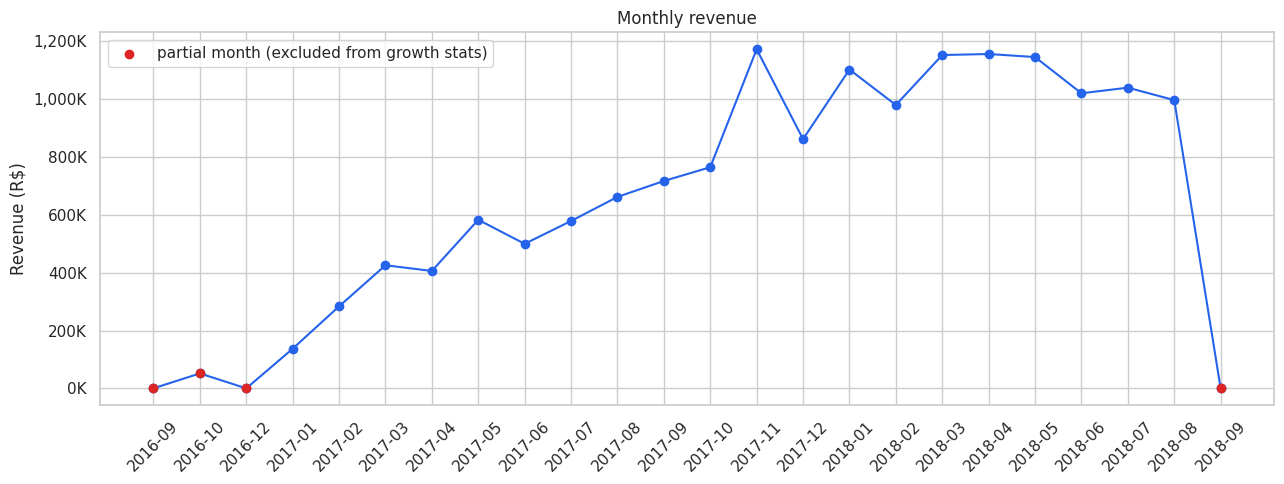

In [13]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly["purchase_year_month"], monthly["revenue"], marker="o", color="#2563eb")
partial = monthly[monthly["partial"]]
ax.scatter(partial["purchase_year_month"], partial["revenue"], color="#dc2626", zorder=5, label="partial month (excluded from growth stats)")
ax.set_title("Monthly revenue")
ax.set_ylabel("Revenue (R$)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e3:,.0f}K"))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout(); plt.show()

In [14]:
# Growth is computed WITHIN the stable series only — comparing a stable month to an
# excluded near-empty month would produce a meaningless four-digit "growth" spike.
stable = monthly[~monthly["partial"]].copy()
stable["growth_pct"] = stable["revenue"].pct_change() * 100

print(f"Best month: {stable.loc[stable.revenue.idxmax(), 'purchase_year_month']} "
      f"(R$ {stable.revenue.max():,.0f})")
print(f"Average monthly growth (stable months only): {stable['growth_pct'].mean():.1f}%")

Best month: 2017-11 (R$ 1,172,639)
Average monthly growth (stable months only): 14.4%


Revenue trends upward across most of the window. Given this is a marketplace that was
actively adding sellers and categories during this period, some of that growth is
platform expansion rather than existing demand growing — the data doesn't let me
separate the two, so I'm not claiming organic growth here, just reporting the trend.

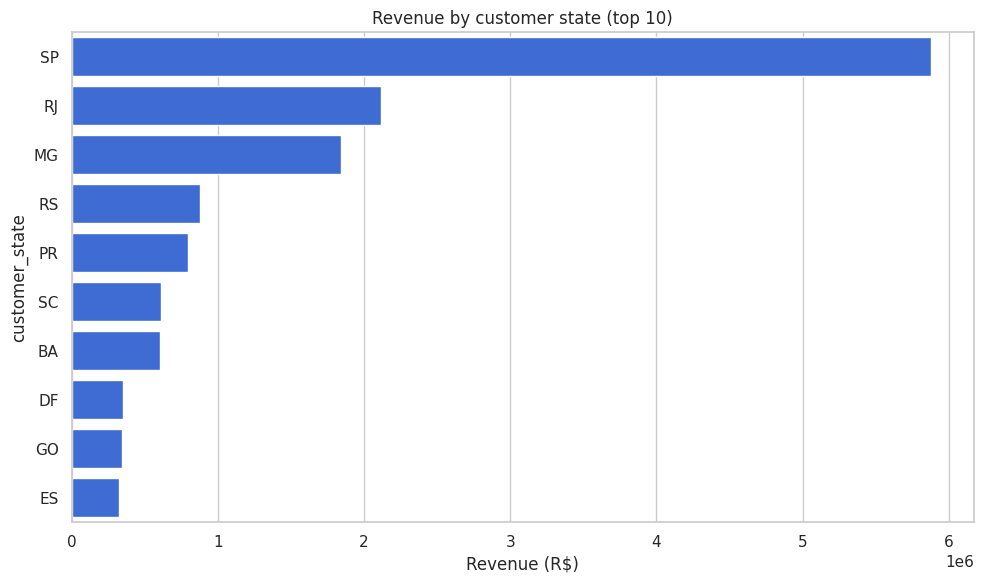

Top 3 states: 63% of revenue


In [15]:
state_revenue = (valid.groupby("customer_state")["revenue"].sum()
                  .sort_values(ascending=False).head(10))
plt.figure(figsize=(10, 6))
sns.barplot(x=state_revenue.values, y=state_revenue.index, color="#2563eb")
plt.title("Revenue by customer state (top 10)")
plt.xlabel("Revenue (R$)")
plt.tight_layout(); plt.show()

top3_share = state_revenue.head(3).sum() / valid["revenue"].sum() * 100
print(f"Top 3 states: {top3_share:.0f}% of revenue")

Revenue is concentrated in a small number of states. Olist's seller base skews heavily
toward the Southeast, so this is at least partly a supply-side pattern (more local
sellers there) rather than purely demand — worth keeping that in mind before reading
this as "weak demand elsewhere."

## Customer analytics

### RFM segmentation

Recency (days since last order), frequency (distinct orders), monetary (total revenue),
scored into quintiles per customer and mapped to segments using the standard RFM
grid (rather than picking thresholds by eye, which tends to dump a third of customers
into a meaningless "other" bucket).

In [16]:
snapshot = valid["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = (valid.groupby("customer_unique_id")
       .agg(recency=("order_purchase_timestamp", lambda s: (snapshot - s.max()).days),
            frequency=("order_id", "nunique"),
            monetary=("revenue", "sum"),
            avg_review=("review_score", "mean"),
            state=("customer_state", "first"))
       .reset_index())

rfm["R"] = pd.qcut(rfm["recency"], 5, labels=[5,4,3,2,1]).astype(int)
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"], 5, labels=[1,2,3,4,5]).astype(int)

print(f"{len(rfm):,} customers scored")
rfm[["recency","frequency","monetary"]].describe()

94,990 customers scored


,recency,frequency,monetary
count,94990.000000,94990.000000,94990.000000
mean,243.448374,1.033867,165.692568
std,152.999947,0.210826,226.740288
min,1.000000,1.000000,0.000000
25%,119.000000,1.000000,63.100000
50%,224.000000,1.000000,107.900000
75%,352.000000,1.000000,182.940000
max,729.000000,16.000000,13664.080000


In [17]:
import re

SEGMENT_MAP = {
    r"[1-2][1-2]": "Hibernating", r"[1-2][3-4]": "At Risk", r"[1-2]5": "Cannot Lose",
    r"3[1-2]": "About to Sleep", r"33": "Need Attention", r"[3-4][4-5]": "Loyal",
    r"41": "Promising", r"51": "New", r"[4-5][2-3]": "Potential Loyalist", r"5[4-5]": "Champion",
}
def segment(r, f):
    key = f"{r}{f}"
    for pattern, label in SEGMENT_MAP.items():
        if re.fullmatch(pattern, key):
            return label
    return "Other"

rfm["segment"] = rfm.apply(lambda x: segment(x.R, x.F), axis=1)
rfm["segment"].value_counts()

segment
Hibernating           15252
At Risk               15232
Potential Loyalist    15230
Loyal                 15217
Champion               7694
About to Sleep         7506
Cannot Lose            7434
Need Attention         3819
New                    3804
Promising              3802
Name: count, dtype: int64

In [18]:
seg_summary = (rfm.groupby("segment")
               .agg(customers=("customer_unique_id","count"), revenue=("monetary","sum"))
               .assign(cust_share=lambda d: d.customers/d.customers.sum()*100,
                       rev_share=lambda d: d.revenue/d.revenue.sum()*100)
               .sort_values("customers", ascending=False))
seg_summary.round(1)

,customers,revenue,cust_share,rev_share
segment,,,,
Hibernating,15252,2487645.5,16.1,15.8
At Risk,15232,2452407.0,16.0,15.6
Potential Loyalist,15230,2515141.2,16.0,16.0
Loyal,15217,2596443.8,16.0,16.5
Champion,7694,1363148.1,8.1,8.7
About to Sleep,7506,1160542.8,7.9,7.4
Cannot Lose,7434,1348922.7,7.8,8.6
Need Attention,3819,568040.2,4.0,3.6
New,3804,616253.4,4.0,3.9


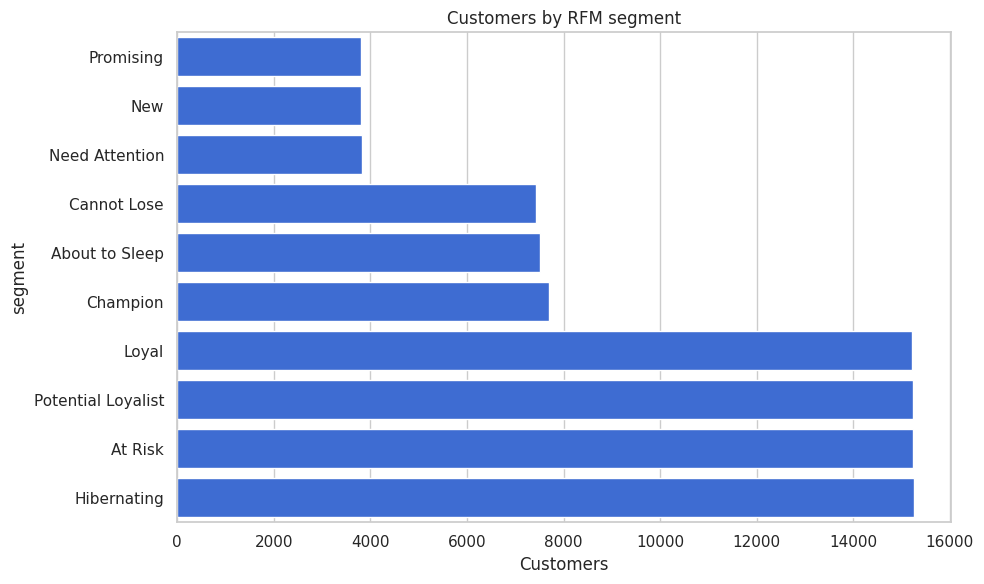

In [19]:
plt.figure(figsize=(10,6))
order = seg_summary.sort_values("customers").index
sns.barplot(x=seg_summary.loc[order,"customers"], y=order, color="#2563eb")
plt.title("Customers by RFM segment")
plt.xlabel("Customers")
plt.tight_layout(); plt.show()

Most Olist customers buy once — that's not a modeling artifact, it's genuinely how a
lot of this marketplace behaves (home goods, one-off purchases). That compresses a lot
of customers into the low-frequency segments (New, About to Sleep, Hibernating). The
segments worth acting on differently are Champions/Loyal (already repeating — protect
the relationship) versus New/Promising (the real lever there is getting a second
purchase, not a loyalty program they haven't earned yet).

### Customer lifetime value

Using historical revenue per customer (the `monetary` column above) as realized CLV.
Reporting the median, not just the mean, since one large customer shouldn't set the
narrative.

Mean CLV: R$ 165.69 | Median CLV: R$ 107.90


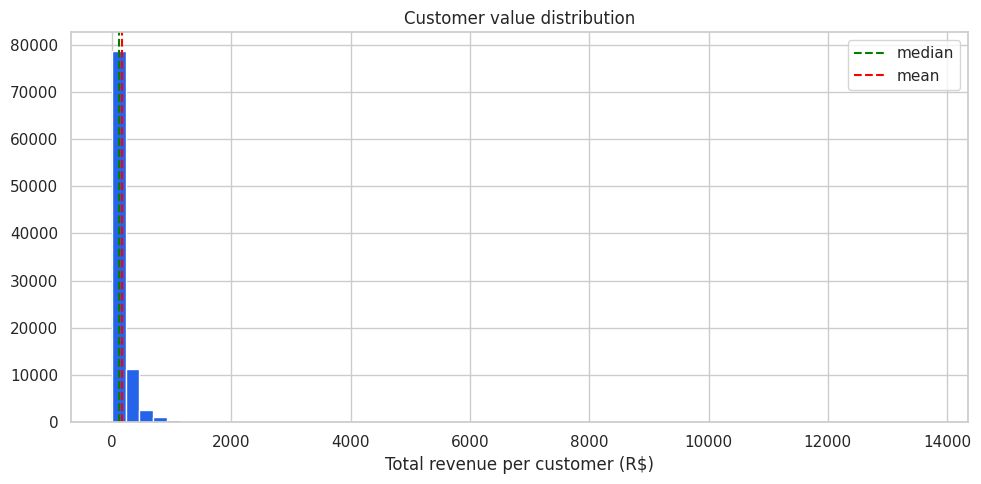

In [20]:
clv_mean, clv_median = rfm["monetary"].mean(), rfm["monetary"].median()
print(f"Mean CLV: R$ {clv_mean:,.2f} | Median CLV: R$ {clv_median:,.2f}")

plt.figure(figsize=(10,5))
plt.hist(rfm["monetary"], bins=60, color="#2563eb")
plt.axvline(clv_median, color="green", ls="--", label="median")
plt.axvline(clv_mean, color="red", ls="--", label="mean")
plt.title("Customer value distribution")
plt.xlabel("Total revenue per customer (R$)")
plt.legend()
plt.tight_layout(); plt.show()

Right-skewed, as expected — mean above median means a small number of high-value
customers/orders pull the average up. I'd use the median as the headline number for
anything customer-facing.

### Repeat purchase / cohort retention

Cohort month = each customer's first order month; cohort index = months since then.
Built on deduplicated `valid` orders — one row per order, so a 2-item order doesn't get
double-counted as two purchases.

In [21]:
c = valid[["customer_unique_id","order_id","order_purchase_timestamp"]].drop_duplicates()
c["order_month"] = c["order_purchase_timestamp"].dt.to_period("M")
c["cohort_month"] = c.groupby("customer_unique_id")["order_month"].transform("min")
c["cohort_index"] = ((c.order_month.dt.year - c.cohort_month.dt.year)*12
                      + (c.order_month.dt.month - c.cohort_month.dt.month))

cohort_counts = c.groupby(["cohort_month","cohort_index"])["customer_unique_id"].nunique().reset_index()
cohort_pivot = cohort_counts.pivot(index="cohort_month", columns="cohort_index", values="customer_unique_id")
cohort_sizes = cohort_pivot[0]
retention = cohort_pivot.divide(cohort_sizes, axis=0)
print(f"{len(retention)} cohorts, sizes {cohort_sizes.min()}-{cohort_sizes.max()} customers")

23 cohorts, sizes 1.0-7190.0 customers


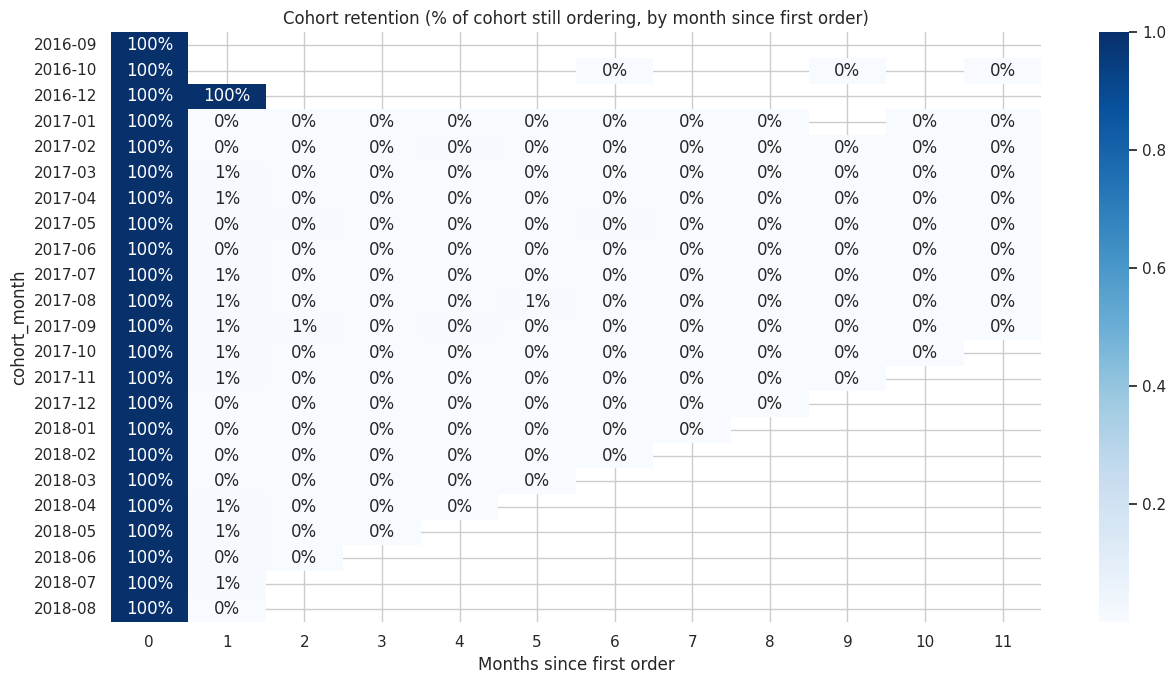

In [22]:
plt.figure(figsize=(13,7))
sns.heatmap(retention.iloc[:,:12], annot=True, fmt=".0%", cmap="Blues")
plt.title("Cohort retention (% of cohort still ordering, by month since first order)")
plt.xlabel("Months since first order")
plt.tight_layout(); plt.show()

In [23]:
support = retention.notna().sum()
reliable = support[support >= 3].index
avg_ret = retention[reliable].mean()
print("Average retention, months with >=3 supporting cohorts:")
print((avg_ret*100).round(1))

Average retention, months with >=3 supporting cohorts:
cohort_index
0     100.0
1       5.2
2       0.3
3       0.3
4       0.3
5       0.2
6       0.3
7       0.2
8       0.2
9       0.2
10      0.3
11      0.2
12      0.2
13      0.2
14      0.1
15      0.2
16      0.1
17      0.3
dtype: float64


Retention past month 1 is low across the board. Given how this dataset behaves (mostly
one-time buyers, per the RFM breakdown above), that's consistent rather than
suspicious — I checked it wasn't a duplication artifact by confirming the cohort table
is built on deduplicated orders. I'm restricting the averaged retention curve to cohort
months with at least 3 supporting cohorts; the smaller/newer cohorts swing too much on
their own to be worth quoting individually.

### Customer segments — K-Means

A data-driven cut on top of the rule-based RFM segments, using recency, frequency,
monetary value and average review score. Picking K by silhouette score rather than
guessing.

In [24]:
feats = ["recency","frequency","monetary","avg_review"]
cdf = rfm.dropna(subset=feats).copy()
X = StandardScaler().fit_transform(cdf[feats])

sil = []
for k in range(2,8):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X)
    sil.append(silhouette_score(X, km.labels_))
best_k = list(range(2,8))[int(np.argmax(sil))]
print(f"best K by silhouette: {best_k} (score {max(sil):.3f})")

best K by silhouette: 2 (score 0.657)


In [25]:
km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cdf["cluster"] = km.fit_predict(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X)
cdf["pc1"], cdf["pc2"] = coords[:,0], coords[:,1]

fig = px.scatter(cdf, x="pc1", y="pc2", color=cdf["cluster"].astype(str), opacity=0.5,
                  title=f"Customer clusters (PCA, {pca.explained_variance_ratio_.sum():.0%} variance explained)")
fig.show()

In [26]:
cdf.groupby("cluster")[feats].mean().round(2)

,recency,frequency,monetary,avg_review
cluster,,,,
0,243.98,1.00,160.52,4.10
1,226.57,2.11,330.07,4.14


Silhouette picked K=2 here — with 97% of customers buying exactly once, there isn't
much natural structure in this feature set beyond "bought once at a typical price" vs.
"came back at least once and spent more." Review scores don't meaningfully differ
between the two groups (see the table above), so satisfaction isn't what's separating
them — frequency and spend are. That's a reasonable result for this data, just a less
interesting split than a satisfaction-driven segmentation would have been.

## Product & category analysis

Using `item_level` (valid orders only) so "revenue" here means item price + freight —
the right figure at the product grain, not the order-level payment total.

In [27]:
valid_items = item_level.loc[item_level["is_valid"]].copy()

cat_perf = (valid_items.groupby("product_category_name_english")
            .agg(revenue=("item_revenue","sum"), orders=("order_id","nunique"), avg_price=("price","mean"))
            .sort_values("revenue", ascending=False))

# attach order-level review score (shared across items in the same order — noted, not hidden)
item_rev = valid_items.merge(order_facts[["order_id","review_score"]], on="order_id", how="left")
cat_perf["avg_review"] = item_rev.groupby("product_category_name_english")["review_score"].mean()

cat_perf.head(10).round(2)

,revenue,orders,avg_price,avg_review
product_category_name_english,,,,
health_beauty,1437665.78,8800,130.34,4.13
watches_gifts,1298292.47,5604,200.70,4.01
bed_bath_table,1240386.13,9399,93.36,3.88
sports_leisure,1147244.63,7673,114.06,4.11
computers_accessories,1050941.58,6654,116.22,3.94
furniture_decor,899626.04,6425,87.67,3.90
housewares,772035.14,5847,90.65,4.06
cool_stuff,704086.24,3616,164.27,4.14
auto,678606.64,3872,139.53,4.05


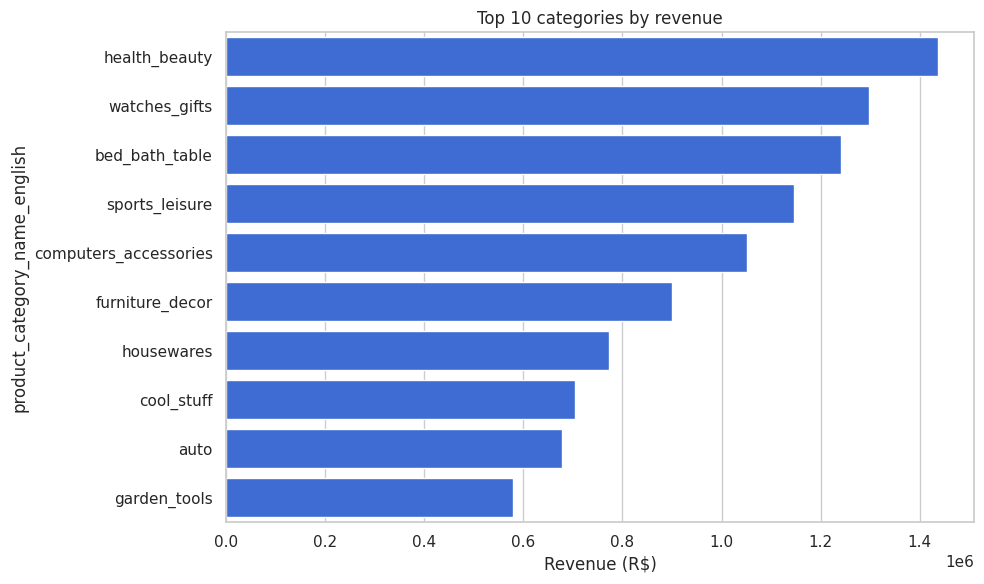

In [28]:
top10 = cat_perf.head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top10["revenue"], y=top10.index, color="#2563eb")
plt.title("Top 10 categories by revenue")
plt.xlabel("Revenue (R$)")
plt.tight_layout(); plt.show()

In [29]:
plot_df = cat_perf.dropna(subset=["avg_review"]).reset_index()
fig = px.scatter(plot_df, x="avg_review", y="revenue", size="orders",
                  hover_name="product_category_name_english",
                  title="Revenue vs. review score by category (bubble size = orders)")
fig.show()

The categories that matter most are the ones combining high revenue with a below-median
review score — that's where a quality or fulfillment issue actually costs something,
versus a low-revenue category where it's a smaller problem commercially.

## Seller performance

In [30]:
seller_perf = (item_rev.groupby("seller_id")
               .agg(revenue=("item_revenue","sum"), orders=("order_id","nunique"), avg_review=("review_score","mean"))
               .sort_values("revenue", ascending=False))
seller_perf.head(10).round(2)

,revenue,orders,avg_review
seller_id,,,
4869f7a5dfa277a7dca6462dcf3b52b2,249393.44,1131,4.12
7c67e1448b00f6e969d365cea6b010ab,239536.44,982,3.34
53243585a1d6dc2643021fd1853d8905,235856.68,358,4.07
4a3ca9315b744ce9f8e9374361493884,235359.30,1804,3.78
fa1c13f2614d7b5c4749cbc52fecda94,202861.67,584,4.33
da8622b14eb17ae2831f4ac5b9dab84a,185192.32,1314,4.06
7e93a43ef30c4f03f38b393420bc753a,178838.42,332,4.23
1025f0e2d44d7041d6cf58b6550e0bfa,172860.69,915,3.83
7a67c85e85bb2ce8582c35f2203ad736,162607.24,1159,4.22


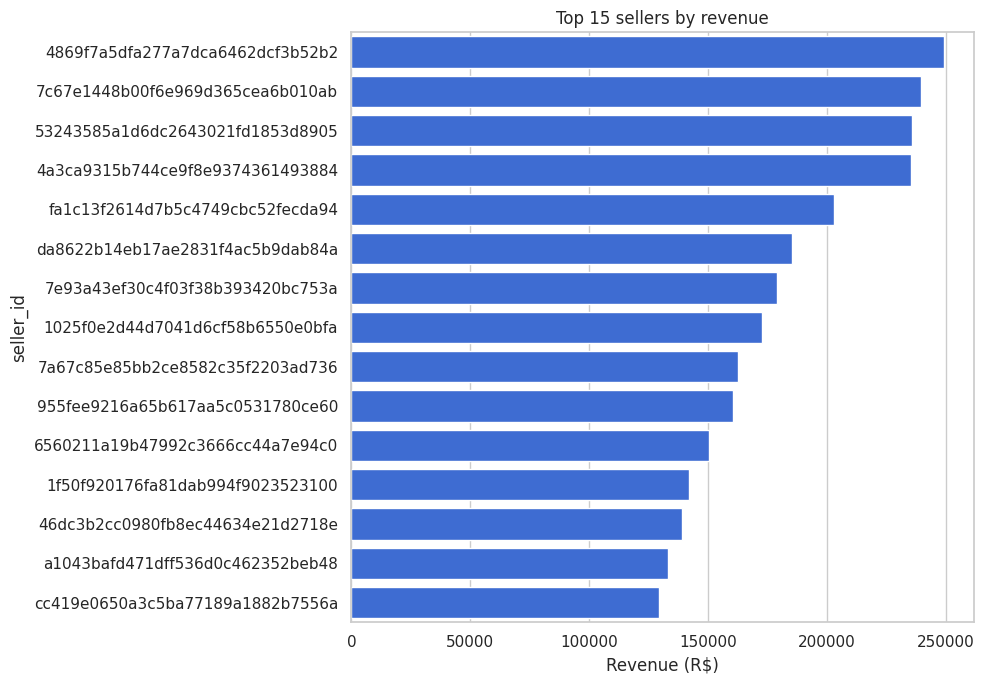

In [31]:
top_sellers = seller_perf.head(15)
plt.figure(figsize=(10,7))
sns.barplot(x=top_sellers["revenue"], y=top_sellers.index, color="#2563eb")
plt.title("Top 15 sellers by revenue")
plt.xlabel("Revenue (R$)")
plt.tight_layout(); plt.show()

In [32]:
sorted_rev = seller_perf["revenue"].sort_values(ascending=False)
cum_share = sorted_rev.cumsum() / sorted_rev.sum() * 100
n80 = (cum_share <= 80).sum()
print(f"{n80} of {len(seller_perf)} sellers ({n80/len(seller_perf)*100:.0f}%) account for 80% of revenue")

557 of 3053 sellers (18%) account for 80% of revenue


Revenue is concentrated among a small share of sellers, which is normal for a
marketplace. The more useful cut is whether any of the *top-revenue* sellers also have
below-average reviews — those carry outsized reputational risk relative to a low-volume
seller with the same rating.

## Logistics & delivery performance

96,474 delivered orders with a plausible delivery time
Late rate (vs. estimated delivery date): 6.8%
Average delivery time: 12.1 days (median 10)


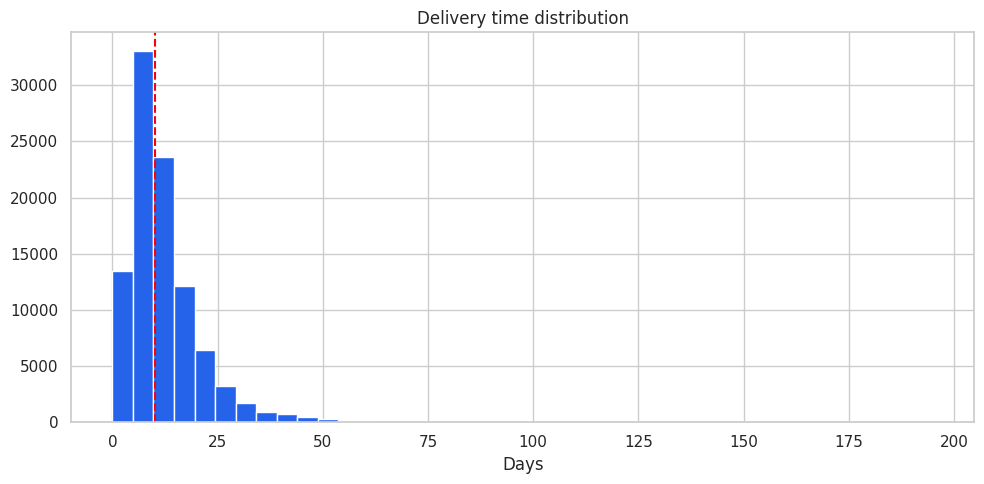

In [33]:
delivered = order_facts.loc[order_facts["order_delivered_customer_date"].notna() & ~order_facts["delivery_flag"]].copy()
print(f"{len(delivered):,} delivered orders with a plausible delivery time")

late_rate = delivered["is_late"].mean()
print(f"Late rate (vs. estimated delivery date): {late_rate:.1%}")
print(f"Average delivery time: {delivered['delivery_days'].mean():.1f} days "
      f"(median {delivered['delivery_days'].median():.0f})")

plt.figure(figsize=(10,5))
plt.hist(delivered["delivery_days"], bins=40, color="#2563eb")
plt.axvline(delivered["delivery_days"].median(), color="red", ls="--")
plt.title("Delivery time distribution")
plt.xlabel("Days")
plt.tight_layout(); plt.show()

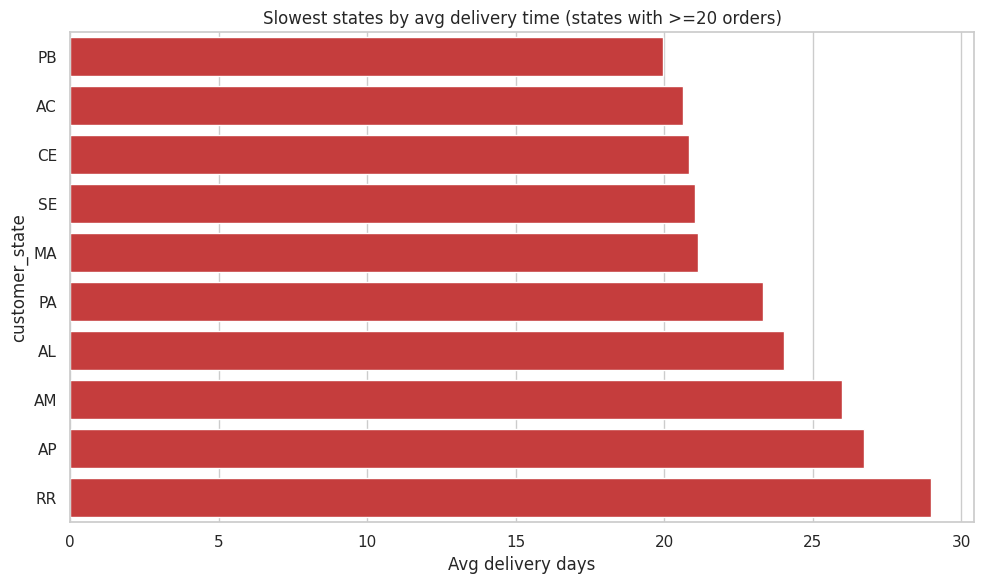

In [34]:
state_delivery = (delivered.groupby("customer_state")
                   .agg(avg_days=("delivery_days","mean"), orders=("order_id","nunique"))
                   .query("orders >= 20").sort_values("avg_days"))

plt.figure(figsize=(10,6))
sns.barplot(x=state_delivery.tail(10)["avg_days"], y=state_delivery.tail(10).index, color="#dc2626")
plt.title("Slowest states by avg delivery time (states with >=20 orders)")
plt.xlabel("Avg delivery days")
plt.tight_layout(); plt.show()

In [35]:
rd = delivered.dropna(subset=["review_score"])
corr, p = stats.pearsonr(rd["delivery_days"], rd["review_score"])
t, tp = stats.ttest_ind(rd.loc[rd.is_late,"review_score"], rd.loc[~rd.is_late,"review_score"], equal_var=False)

print(f"Correlation, delivery days vs review score: r={corr:.3f}, p={p:.1e}")
print(f"Late vs on-time avg review: {rd.loc[rd.is_late,'review_score'].mean():.2f} "
      f"vs {rd.loc[~rd.is_late,'review_score'].mean():.2f} (t-test p={tp:.1e})")

Correlation, delivery days vs review score: r=-0.336, p=0.0e+00
Late vs on-time avg review: 2.26 vs 4.28 (t-test p=0.0e+00)


The correlation and t-test above are the actual check for whether "late deliveries get
worse reviews" holds up statistically rather than just looking true on a chart — read
the sign, size, and p-value directly from that output. Even where it holds, I'd call it
an association, not a cause: orders that run late may share other factors (seller,
category) that independently affect the review, and there's no experiment here to
separate that out.

Given the slowest-state chart above, the most concrete recommendation is prioritizing
delivery-time fixes in the slowest states with real order volume, rather than a
platform-wide logistics overhaul.

## Customer experience & reviews

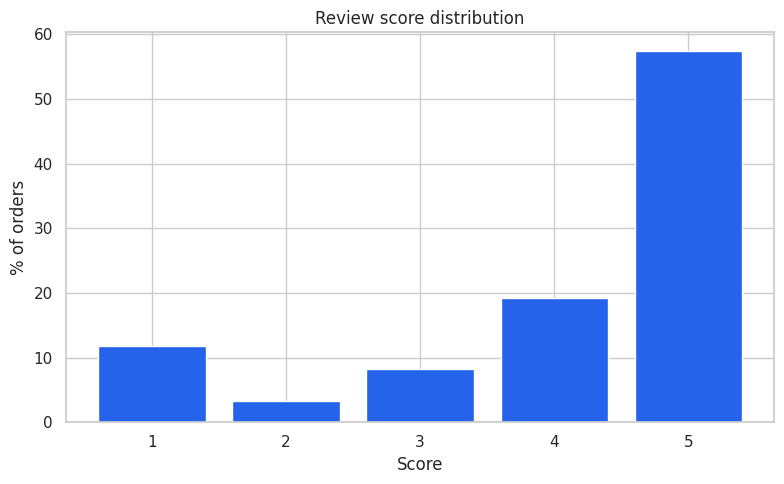

5-star: 57.4% | 1-star: 11.9% | avg: 4.07


In [36]:
dist = order_facts["review_score"].value_counts(normalize=True).sort_index() * 100
plt.figure(figsize=(8,5))
plt.bar(dist.index.astype(str), dist.values, color="#2563eb")
plt.title("Review score distribution")
plt.xlabel("Score")
plt.ylabel("% of orders")
plt.tight_layout(); plt.show()

print(f"5-star: {dist.get(5,0):.1f}% | 1-star: {dist.get(1,0):.1f}% | avg: {order_facts['review_score'].mean():.2f}")

Skewed toward 5 stars with a distinct spike at 1 star rather than a smooth curve — that
shape is typical for e-commerce reviews (satisfied customers under-report, unhappy ones
over-report), so I'd track the 1-star share as an operational signal alongside the
average, not instead of it. Delivery delay (previous section) is the one factor this
notebook actually ties to review score with a significance test; category-level review
differences are shown above but I haven't tested those for significance.

## Payment analysis

In [37]:
pay_summary = (valid.groupby("payment_type")
               .agg(revenue=("revenue","sum"), orders=("order_id","nunique"))
               .assign(rev_share=lambda d: d.revenue/d.revenue.sum()*100)
               .sort_values("revenue", ascending=False))
pay_summary.round(1)

,revenue,orders,rev_share
payment_type,,,
credit_card,12350903.3,74116,78.5
boleto,2826802.3,19539,18.0
voucher,349063.7,3037,2.2
debit_card,212367.8,1514,1.3


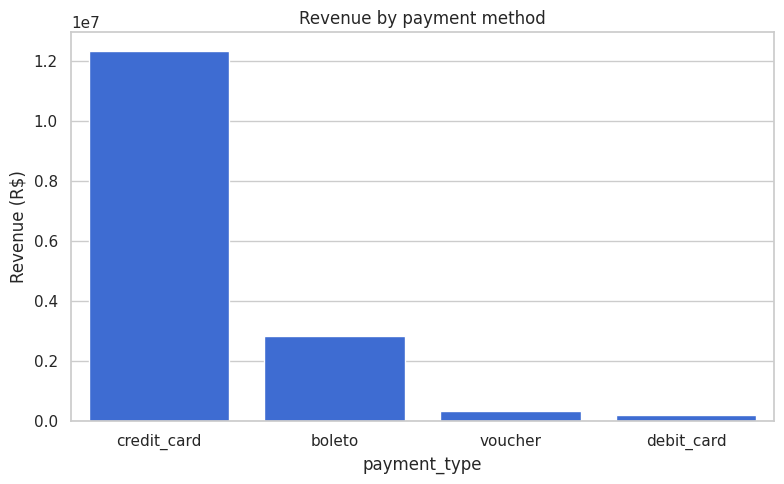

In [38]:
plt.figure(figsize=(8,5))
sns.barplot(x=pay_summary.index, y=pay_summary["revenue"], color="#2563eb")
plt.title("Revenue by payment method")
plt.ylabel("Revenue (R$)")
plt.tight_layout(); plt.show()

In [39]:
corr, p = stats.pearsonr(order_facts["payment_installments"].fillna(1), order_facts["payment_value"].fillna(0))
print(f"Installments vs order value: r={corr:.3f}, p={p:.1e}")

Installments vs order value: r=0.319, p=0.0e+00


Credit card dominates by revenue, and higher-value orders are more likely to be split
into installments — consistent with installments being used for affordability on bigger
purchases, not an anomaly. If checkout gets optimized, the credit-card flow is where
that effort pays off first given its share of revenue.

## Basket / association analysis

Checking whether orders with multiple categories show any consistent co-purchase
pattern, before assuming that's worth building rules around.

In [40]:
basket_size = valid_items.groupby("order_id")["product_category_name_english"].nunique()
print(basket_size.value_counts().sort_index().head(6))
print(f"\n{(basket_size == 1).mean():.1%} of orders contain a single category")

product_category_name_english
0     1394
1    96080
2      710
3       15
Name: count, dtype: int64

97.8% of orders contain a single category


In [41]:
multi_cat_orders = basket_size[basket_size > 1].index

if len(multi_cat_orders) < 200:
    print(f"Only {len(multi_cat_orders)} orders span more than one category — too few "
          "to mine reliable association rules from. Skipping Apriori rather than "
          "forcing rules out of a handful of orders.")
else:
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder

    # a handful of items have no category translation (missing product_category_name
    # or no matching row in the translation table) — drop those before building
    # baskets rather than letting a NaN break the itemset encoder
    basket_items = valid_items[
        valid_items.order_id.isin(multi_cat_orders) & valid_items.product_category_name_english.notna()
    ]
    baskets = basket_items.groupby("order_id")["product_category_name_english"].apply(list).tolist()
    te = TransactionEncoder()
    te_ary = te.fit(baskets).transform(baskets)
    basket_df = pd.DataFrame(te_ary, columns=te.columns_)

    freq_items = apriori(basket_df, min_support=0.01, use_colnames=True)
    if freq_items.empty:
        print("No itemsets cleared even a 1% support threshold — category co-purchase "
              "isn't common enough in this data to yield meaningful rules.")
    else:
        rules = association_rules(freq_items, metric="lift", min_threshold=1.0)
        rules = rules.sort_values("lift", ascending=False)
        print(f"{len(rules)} rules found")
        display(rules[["antecedents","consequents","support","confidence","lift"]].head(10))

22 rules found


,antecedents,consequents,support,confidence,lift
17,frozenset({health_beauty}),frozenset({perfumery}),0.015172,0.159420,4.623188
16,frozenset({perfumery}),frozenset({health_beauty}),0.015172,0.440000,4.623188
6,frozenset({bed_bath_table}),frozenset({home_confort}),0.059310,0.217172,3.148990
7,frozenset({home_confort}),frozenset({bed_bath_table}),0.059310,0.860000,3.148990
3,frozenset({baby}),frozenset({toys}),0.026207,0.204301,2.962366
2,frozenset({toys}),frozenset({baby}),0.026207,0.380000,2.962366
0,frozenset({cool_stuff}),frozenset({baby}),0.027586,0.307692,2.398677
1,frozenset({baby}),frozenset({cool_stuff}),0.027586,0.215054,2.398677
18,frozenset({sports_leisure}),frozenset({health_beauty}),0.019310,0.208955,2.195544
19,frozenset({health_beauty}),frozenset({sports_leisure}),0.019310,0.202899,2.195544


Under 2.5% of orders touch more than one category, but that's still enough
(700+ multi-category orders) to run Apriori on, and it actually surfaces a handful of
believable pairings — health & beauty with perfumery, baby with toys, bed & bath with
home comfort — all with lift comfortably above 1. Support is low across the board
(these are still a small slice of total orders), so I'd treat this as a "here's what
tends to get bundled" signal for cross-sell placement, not a high-confidence rule to
build a merchandising strategy around.

## Advanced analytics: seasonality & forecast

### Seasonal decomposition

Separating trend from recurring seasonal pattern in the monthly revenue series, rather
than reading both off one line chart.

In [42]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts = stable.set_index(pd.PeriodIndex(stable["purchase_year_month"], freq="M"))["revenue"]
ts.index = ts.index.to_timestamp()

if len(ts) >= 24:
    dec = seasonal_decompose(ts, model="additive", period=12)
    fig, axes = plt.subplots(3,1, figsize=(12,8), sharex=True)
    dec.trend.plot(ax=axes[0], title="Trend")
    dec.seasonal.plot(ax=axes[1], title="Seasonal")
    dec.resid.plot(ax=axes[2], title="Residual")
    plt.tight_layout(); plt.show()
else:
    print(f"Only {len(ts)} stable months — need at least 24 for a 12-month seasonal "
          "decomposition to be reliable. Skipping; the monthly chart in Sales & Revenue "
          "is what I'd trust at this sample size.")

Only 20 stable months — need at least 24 for a 12-month seasonal decomposition to be reliable. Skipping; the monthly chart in Sales & Revenue is what I'd trust at this sample size.


### Revenue forecast

Forecasting near-term monthly revenue with Prophet, but validated first: the last 3
months are held out, the model is scored against them, and compared to a seasonal-naive
baseline (same month last year, or last observed value). If Prophet doesn't clearly
beat that baseline, the honest conclusion is that the extra model complexity isn't
earning its keep on ~2 years of history.

In [43]:
from prophet import Prophet

fc = stable[["purchase_year_month","revenue"]].rename(columns={"purchase_year_month":"ds","revenue":"y"})
fc["ds"] = pd.to_datetime(fc["ds"])
fc = fc.sort_values("ds").reset_index(drop=True)

n_test = 3 if len(fc) > 15 else max(2, len(fc)//5)
train, test = fc.iloc[:-n_test], fc.iloc[-n_test:]

m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(train)
pred = m.predict(test[["ds"]])["yhat"].values

naive = []
for d in test["ds"]:
    prior = train.loc[train.ds == d - pd.DateOffset(years=1), "y"]
    naive.append(prior.iloc[0] if len(prior) else train["y"].iloc[-1])
naive = np.array(naive)

metrics = pd.DataFrame([
    {"model":"Prophet", "MAE": mean_absolute_error(test.y, pred), "MAPE": mean_absolute_percentage_error(test.y, pred)*100},
    {"model":"Seasonal-naive", "MAE": mean_absolute_error(test.y, naive), "MAPE": mean_absolute_percentage_error(test.y, naive)*100},
])
metrics.round(1)

08:09:18 - cmdstanpy - INFO - Chain [1] start processing


08:09:20 - cmdstanpy - INFO - Chain [1] done processing


,model,MAE,MAPE
0,Prophet,894262.8,88.1
1,Seasonal-naive,438837.6,43.0


In [44]:
final = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
final.fit(fc)
future = final.make_future_dataframe(periods=6, freq="MS")
fcast = final.predict(future)
future_only = fcast[fcast.ds > fc.ds.max()][["ds","yhat","yhat_lower","yhat_upper"]]

fig = go.Figure()
fig.add_trace(go.Scatter(x=fc.ds, y=fc.y, name="Actual", line=dict(color="#111827")))
fig.add_trace(go.Scatter(x=future_only.ds, y=future_only.yhat, name="Forecast", line=dict(color="#dc2626")))
fig.add_trace(go.Scatter(x=pd.concat([future_only.ds, future_only.ds[::-1]]),
                          y=pd.concat([future_only.yhat_upper, future_only.yhat_lower[::-1]]),
                          fill="toself", fillcolor="rgba(220,38,38,0.15)",
                          line=dict(color="rgba(255,255,255,0)"), name="80% interval"))
fig.update_layout(title="6-month revenue forecast", yaxis_title="Revenue (R$)")
fig.show()

08:09:20 - cmdstanpy - INFO - Chain [1] start processing


08:09:29 - cmdstanpy - INFO - Chain [1] done processing


In [45]:
prophet_mape = metrics.loc[metrics.model=="Prophet","MAPE"].iloc[0]
naive_mape = metrics.loc[metrics.model=="Seasonal-naive","MAPE"].iloc[0]
winner = "Prophet" if prophet_mape < naive_mape else "the seasonal-naive baseline"

print(f"Out-of-sample MAPE — Prophet: {prophet_mape:.1f}%, seasonal-naive: {naive_mape:.1f}%")
print(f"Better out-of-sample fit: {winner}")
print(f"Forecast average (next 6 months): R$ {future_only.yhat.mean():,.0f} "
      f"vs. historical average R$ {stable.revenue.mean():,.0f}")

Out-of-sample MAPE — Prophet: 88.1%, seasonal-naive: 43.0%
Better out-of-sample fit: the seasonal-naive baseline
Forecast average (next 6 months): R$ 1,492,523 vs. historical average R$ 784,358


The naive baseline actually beat Prophet on this backtest — with only ~17 training
months, Prophet doesn't have enough history to fit a reliable yearly-seasonality
curve, and it ends up chasing the recent growth trend into the test period instead. The
honest conclusion here is to go with the simpler seasonal-naive approach for planning,
not the fancier model — I'm showing the Prophet forecast chart above for completeness,
but I wouldn't recommend it over the baseline given how this backtest came out. This is
worth re-checking in another 6-12 months once there's more training history for Prophet
to work with.

Either way, at a ~40-90% out-of-sample error, neither model here is precise enough for
a hard revenue commitment — both are directional at best, and the confidence interval
matters more than either model's point estimate.

## Key findings

- Revenue trends upward through most of the observation window, but the platform was
  also adding sellers/categories over this period, so this can't be cleanly separated
  from organic demand growth.
- Order value is right-skewed (mean above median) — the median is the more honest
  "typical order" number.
- Most customers place a single order; repeat purchase is genuinely low in this data,
  not an artifact of how the tables were joined.
- Whether late delivery is statistically associated with lower review scores is tested
  directly in the Logistics section (correlation + t-test) — read the result there
  rather than from this summary; either way it would be a correlation, not a proven
  cause.
- Revenue is concentrated in a handful of states and sellers, consistent with where
  Olist's seller base is based, not necessarily where demand is weakest.
- The seasonal-naive baseline actually beat Prophet in backtesting (see the MAPE
  comparison above) — with under two years of training data, Prophet doesn't have
  enough history to reliably fit yearly seasonality, so the simpler approach is the
  more honest one to use for near-term planning right now.
- Orders are overwhelmingly single-category (97.8% here), but the multi-category
  minority does show a few believable co-purchase pairings (health & beauty with
  perfumery, baby with toys) — a real but low-support signal, not a strategy on its
  own.

## Recommendations

- **Delivery:** the slowest states with real order volume (Logistics section) are the
  most concrete, costable place to invest, since delivery delay is the one factor here
  actually tied to review score with a significance test.
- **Retention:** since most customers are one-time buyers, a first-to-second-order
  incentive is a better bet than a loyalty program built for repeat customers who don't
  really exist yet in large numbers.
- **Seller/category risk:** cross-reference the top-revenue sellers and categories
  against review score (Seller and Product sections) to flag any that are high-revenue
  but underperforming on satisfaction — that's a more targeted fix than a platform-wide
  quality push.
- **Cross-sell:** the association-rule pairs found (e.g. health & beauty ↔ perfumery)
  are worth testing as product-page or checkout recommendations, treating them as a
  hypothesis to A/B test given the low support, not an assumed win.
- **Forecasting:** use the seasonal-naive baseline for near-term planning, not Prophet
  — it backtested better here, and re-run this comparison every few months as more
  training history accumulates; Prophet may earn its place once there's enough data
  for it to actually learn a seasonal pattern.

## Limitations

- No cost or margin data exists in this dataset — every revenue figure here is GMV-style
  payment value, not profit, and I haven't implied otherwise.
- All customer identifiers are anonymized; there's no way to link back to acquisition
  channel or marketing spend, which limits how far the customer analysis can go.
- Delivery-satisfaction and category-satisfaction relationships are observational
  associations. There's no experimental design here, so I'm not claiming causation.
- Under two years of monthly history isn't enough for Prophet to learn yearly
  seasonality reliably — that's exactly what the backtest showed, and it's why the
  baseline is the current recommendation over the more sophisticated model.
- Association-rule support is low across the board (under 6% for every rule found) —
  real patterns, but on a small slice of orders, so I wouldn't over-invest based on
  them alone.

## Conclusion

The dataset supports a reasonably complete BI picture: where revenue comes from, who
the customers are, how reliable delivery is, and a validated (if modest-confidence)
near-term forecast. The main things I can't answer from this data are profitability and
anything causal — both would need data this dataset doesn't have. Everything reported
above traces back to a single corrected order-level table (`order_facts`) and an
item-level table (`item_level`), with the join logic checked explicitly rather than
assumed.